# Embedded AI — CNN MNIST

**Auteur original :** Kevin Hector (post-doctorant, Mines Saint-Étienne)
**Date :** 20/09/2022
**Modifié par :** Matteo Quintaneiro, 2026

**Description :** CNN pour la reconnaissance de chiffres MNIST, destiné au déploiement sur STM32L4R9 via X-CUBE-AI.

**Modifications apportées :**
- Architecture améliorée : 2 couches Conv2D (8 et 16 filtres) au lieu d'une seule (2 filtres), ajout de Dropout(0.25) et Dense(32)
- Entraînement passé de 5 à 10 epochs
- Ajout d'une cellule de test avec des images custom dessinées à la main
- Correction de la compatibilité Keras 3 (suppression de `lr` déprécié)

## Setup

In [54]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import tensorflow
from tensorflow import keras
from tensorflow.keras import layers, models



---
# Define the model


In [55]:
def build_model(input_shape):

        model = models.Sequential()

        # deux couches conv au lieu d'une, avec plus de filtres
        model.add(layers.Conv2D(8, (3, 3), padding='same', activation='relu', input_shape=input_shape))
        model.add(layers.MaxPooling2D((2, 2)))
        model.add(layers.Conv2D(16, (3, 3), padding='same', activation='relu'))
        model.add(layers.MaxPooling2D((2, 2)))

        model.add(layers.Flatten())
        model.add(layers.Dropout(0.25))
        model.add(layers.Dense(32, activation='relu'))
        model.add(layers.Dense(10, activation='softmax'))

        return model

## Prepare the data

In [56]:
# Model / data parameters
num_classes = 10
input_shape = (28, 28, 1)

# Load the data and split it between train and test sets
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Scale images to the [0, 1] range
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255
# Make sure images have shape (28, 28, 1)
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

x_val = x_train[50000:]
y_val = y_train[50000:]
        
x_train = x_train[:50000]
y_train = y_train[:50000]



print("x_train shape:", x_train.shape)
print(x_train.shape[0], "train samples")
print(x_test.shape[0], "test samples")
print(x_val.shape[0], "validation samples")


# convert class vectors to binary class matrices
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)
y_val = keras.utils.to_categorical(y_val, num_classes)

x_train shape: (50000, 28, 28, 1)
50000 train samples
10000 test samples
10000 validation samples


## Build the model

In [57]:
model = build_model(input_shape)
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 14, 14, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │        25,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,698 (104.29 KB)

 Trainable params: 26,698 (104.29 KB)

 Non-trainable params: 0 (0.00 B)

## Train the model

In [58]:
batch_size = 128
epochs = 10

model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])


history = model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_data=(x_val, y_val), shuffle=True)

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8412 - loss: 0.5095 - val_accuracy: 0.9590 - val_loss: 0.1387
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9521 - loss: 0.1587 - val_accuracy: 0.9734 - val_loss: 0.0894
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9653 - loss: 0.1133 - val_accuracy: 0.9780 - val_loss: 0.0717
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9709 - loss: 0.0929 - val_accuracy: 0.9800 - val_loss: 0.0627
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9747 - loss: 0.0791 - val_accuracy: 0.9823 - val_loss: 0.0571
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9775 - loss: 0.0716 - val_accuracy: 0.9845 - val_loss: 0.0523
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9787 - loss: 0.0642 - val_accuracy: 0.9852 - val_loss: 0.0505
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9814 - loss: 0.0587 - val_accuracy: 0.

## Evaluate the trained model



In [59]:
score = model.evaluate(x_test, y_test, verbose=0)
print("Test loss:", score[0])
print("Test accuracy:", score[1])

Test loss: 0.03584339842200279
Test accuracy: 0.9882000088691711


## Export du modèle

On exporte en TFLite plutôt qu'en .h5 car Keras 3 ajoute un attribut `quantization_config` dans les couches Dense que X-CUBE-AI ne sait pas lire. Le format TFLite contourne ce problème.

In [60]:
# export tflite
converter = tensorflow.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
with open("MNIST_NN_C2_16_10.tflite", "wb") as f:
    f.write(tflite_model)

print(f"Modele TFLite sauvegarde ({len(tflite_model)} octets)")

# sauvegarder aussi le .h5 et les donnees de test
np.save("MNIST_xtest_NN_C2_16_10.npy", x_test)
np.save("MNIST_ytest_NN_C2_16_10.npy", y_test)
model.save("MNIST_NN_C2_16_10.h5")

INFO:tensorflow:Assets written to: C:\Users\matte\AppData\Local\Temp\tmpk_1_oa2j\assets


INFO:tensorflow:Assets written to: C:\Users\matte\AppData\Local\Temp\tmpk_1_oa2j\assets


Saved artifact at 'C:\Users\matte\AppData\Local\Temp\tmpk_1_oa2j'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name='keras_tensor_226')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  2159827563728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2159827561232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2159827564688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2159827561616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2159827565264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2159827565840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2159827563344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2159827562000: TensorSpec(shape=(), dtype=tf.resource, name=None)


Modele TFLite sauvegarde (110960 octets)


## Test avec des images custom

2-test.png -> Predit: 2 (92%)
  Probas: ['0.1%', '0.0%', '92.1%', '7.1%', '0.0%', '0.0%', '0.0%', '0.2%', '0.0%', '0.5%']

3-test.png -> Predit: 3 (99%)
  Probas: ['0.0%', '0.0%', '0.1%', '99.4%', '0.0%', '0.0%', '0.0%', '0.1%', '0.0%', '0.3%']

5-test.png -> Predit: 5 (99%)
  Probas: ['0.0%', '0.0%', '0.0%', '0.1%', '0.0%', '99.9%', '0.0%', '0.0%', '0.0%', '0.0%']

6-test.png -> Predit: 6 (98%)
  Probas: ['0.0%', '0.0%', '0.0%', '0.0%', '0.0%', '1.4%', '98.6%', '0.0%', '0.0%', '0.0%']

7-test.png -> Predit: 7 (96%)
  Probas: ['0.0%', '0.0%', '3.6%', '0.0%', '0.0%', '0.0%', '0.0%', '96.4%', '0.0%', '0.0%']

8-test.png -> Predit: 3 (91%)
  Probas: ['0.0%', '0.0%', '0.0%', '91.3%', '0.0%', '0.2%', '2.1%', '0.0%', '6.0%', '0.4%']



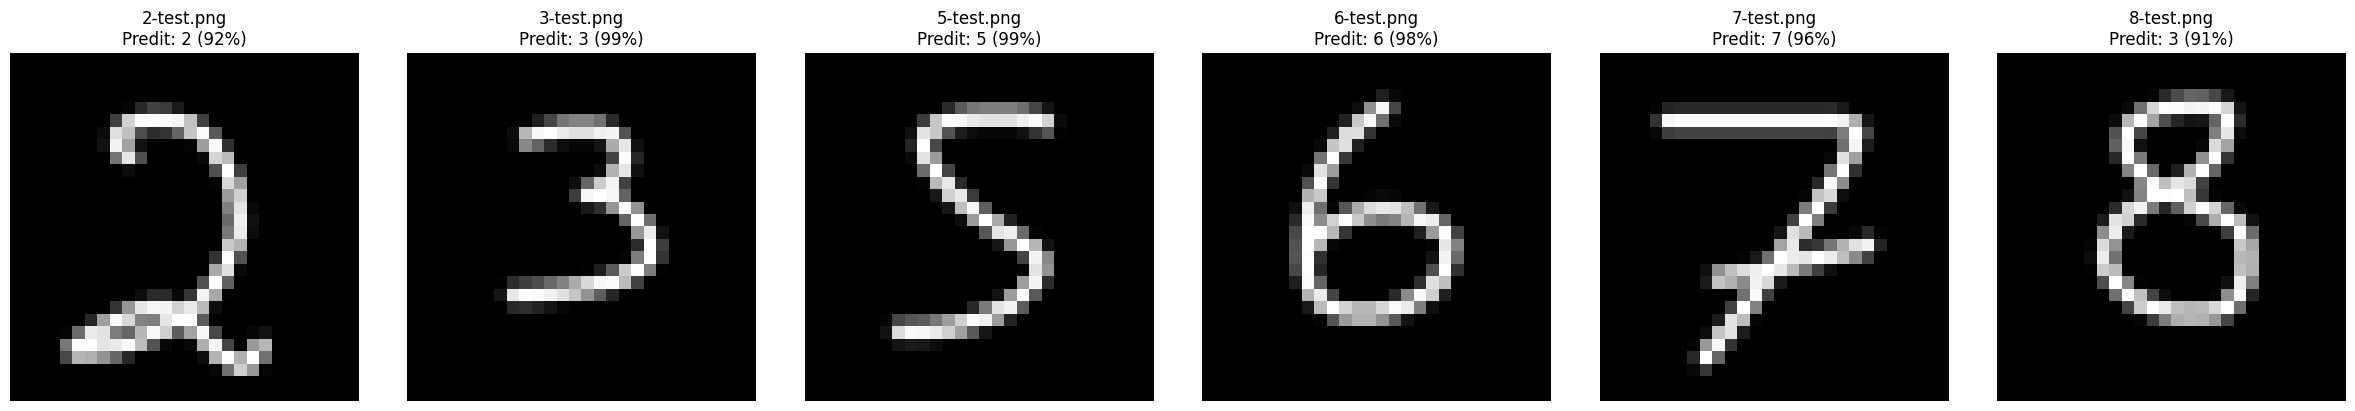

In [62]:
test_images = ["2-test.png", "3-test.png", "5-test.png", "6-test.png", "7-test.png", "8-test.png"]

fig, axes = plt.subplots(1, len(test_images), figsize=(4 * len(test_images), 4))

for i, filename in enumerate(test_images):
    img = Image.open(filename).convert("L")
    img = img.resize((28, 28))

    x = np.array(img).astype("float32") / 255.0
    x = x.reshape(1, 28, 28, 1)

    pred = model.predict(x, verbose=0)
    predicted = np.argmax(pred)
    confidence = int(pred[0][predicted] * 100)

    print(f"{filename} -> Predit: {predicted} ({confidence}%)")
    print(f"  Probas: {[f'{p:.1%}' for p in pred[0]]}\n")

    axes[i].imshow(x[0, :, :, 0], cmap="gray")
    axes[i].set_title(f"{filename}\nPredit: {predicted} ({confidence}%)")
    axes[i].axis("off")

plt.tight_layout()
plt.show()